# questions

    Jak se počet daných hodnocení mění v čase napříč žánry?
    Je zde korelace mezi délkou a počtem hodnocení? – preferují lidé kratší/delší filmy?
    Je zde korelace mezi délkou a průměrným hodnocením ? - preferují lidé kratší/delší filmy?
    Korelace mezi délkou a žánry.

    Which genres are most popular among users in time?
    Is there a correlation between average rating and number of ratings?

---
nebo ještě tohle jako alternativa

https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance/data


In [1]:
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymannkendall as mk

In [2]:
#download and extract dataset
if not os.path.isfile('large-data/title.basics.tsv.gz'):
    response = requests.get('https://datasets.imdbws.com/title.basics.tsv.gz')
    if response.status_code == 200:
        with open("large-data/title.basics.tsv.gz", 'wb') as file:
            file.write(response.content)

df = pd.read_csv('large-data/title.basics.tsv.gz', sep='\t', compression='gzip')

if not os.path.isfile('large-data/title.ratings.tsv.gz'):
    response = requests.get('https://datasets.imdbws.com/title.ratings.tsv.gz')
    if response.status_code == 200:
        with open('large-data/title.ratings.tsv.gz', 'wb') as file:
            file.write(response.content)

df2 = pd.read_csv('large-data/title.ratings.tsv.gz', sep='\t', compression='gzip')
df = pd.merge(df, df2, on='tconst')

/var/folders/n7/xqx0_17x5f736w2ms947w_yr0000gn/T/ipykernel_7107/1238082696.py:8: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('large-data/title.basics.tsv.gz', sep='\t', compression='gzip')


In [3]:
df

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",5.7,2158
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short",5.5,293
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance",6.5,2202
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short",5.3,187
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short,6.2,2943
...,...,...,...,...,...,...,...,...,...,...,...
1569671,tt9916846,tvEpisode,Episode #3.18,Episode #3.18,0,2009,\N,\N,Drama,5.8,6
1569672,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2009,\N,\N,Drama,5.8,6
1569673,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010,\N,\N,Drama,5.8,6
1569674,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010,\N,\N,Drama,5.8,6


In [4]:
df['titleType'].unique()

array(['short', 'movie', 'tvShort', 'tvMovie', 'tvEpisode', 'tvSeries',
       'tvMiniSeries', 'tvSpecial', 'video', 'videoGame'], dtype=object)

In [3]:
movies_df = df[df['titleType'].isin(['movie'])]
del df, df2

The New Hollywood and Global Blockbusters (1970s–Early 1990s)

    American “New Hollywood” cinema: Directors like Martin Scorsese, Francis Ford Coppola, and Steven Spielberg redefined storytelling, creating films that appealed broadly both domestically and abroad.
    Rise of the blockbuster: Films such as "Jaws" (1975) and "Star Wars" (1977) set new standards for production value and marketing, heavily influencing international trends.
    At the same time, global cinema saw continued innovation with directors in various regions experimenting with narrative structure, politics, and style.

In [4]:
#removing rows with nan values
print(f'n of dropped entries: {len(movies_df[movies_df['runtimeMinutes'] == '\\N']) + len(movies_df[movies_df['startYear'] == '\\N'])} from {len(movies_df)}')
movies_df = movies_df[movies_df['runtimeMinutes'] != '\\N']
movies_df = movies_df[movies_df['startYear'] != '\\N']

#making the columns integers
movies_df['startYear'] = movies_df['startYear'].astype(int)
movies_df['runtimeMinutes'] = movies_df['runtimeMinutes'].astype(int)

n of dropped entries: 33466 from 329875


In [7]:
movies_df[['startYear', 'runtimeMinutes']]

,startYear,runtimeMinutes
8,1894,45
144,1897,100
339,1905,100
375,1906,70
385,1907,90
...,...,...
1569597,2020,95
1569604,2020,84
1569609,2020,92
1569620,2019,123


In [5]:
#set the analysed period 
def mov_period(movies_df, cutoff_year=None):
    if cutoff_year is not None:
        filtered = movies_df[movies_df['startYear'] >= cutoff_year]
    else:
        filtered = movies_df
    list_of_lists = filtered.groupby('startYear')['runtimeMinutes'].apply(list).tolist()
    years = sorted(filtered['startYear'].unique().tolist())
    avg_runtimes = [np.mean(lst) for lst in list_of_lists]
    return list_of_lists, years, avg_runtimes

list_of_lists, years, avg_runtimes = mov_period(movies_df)

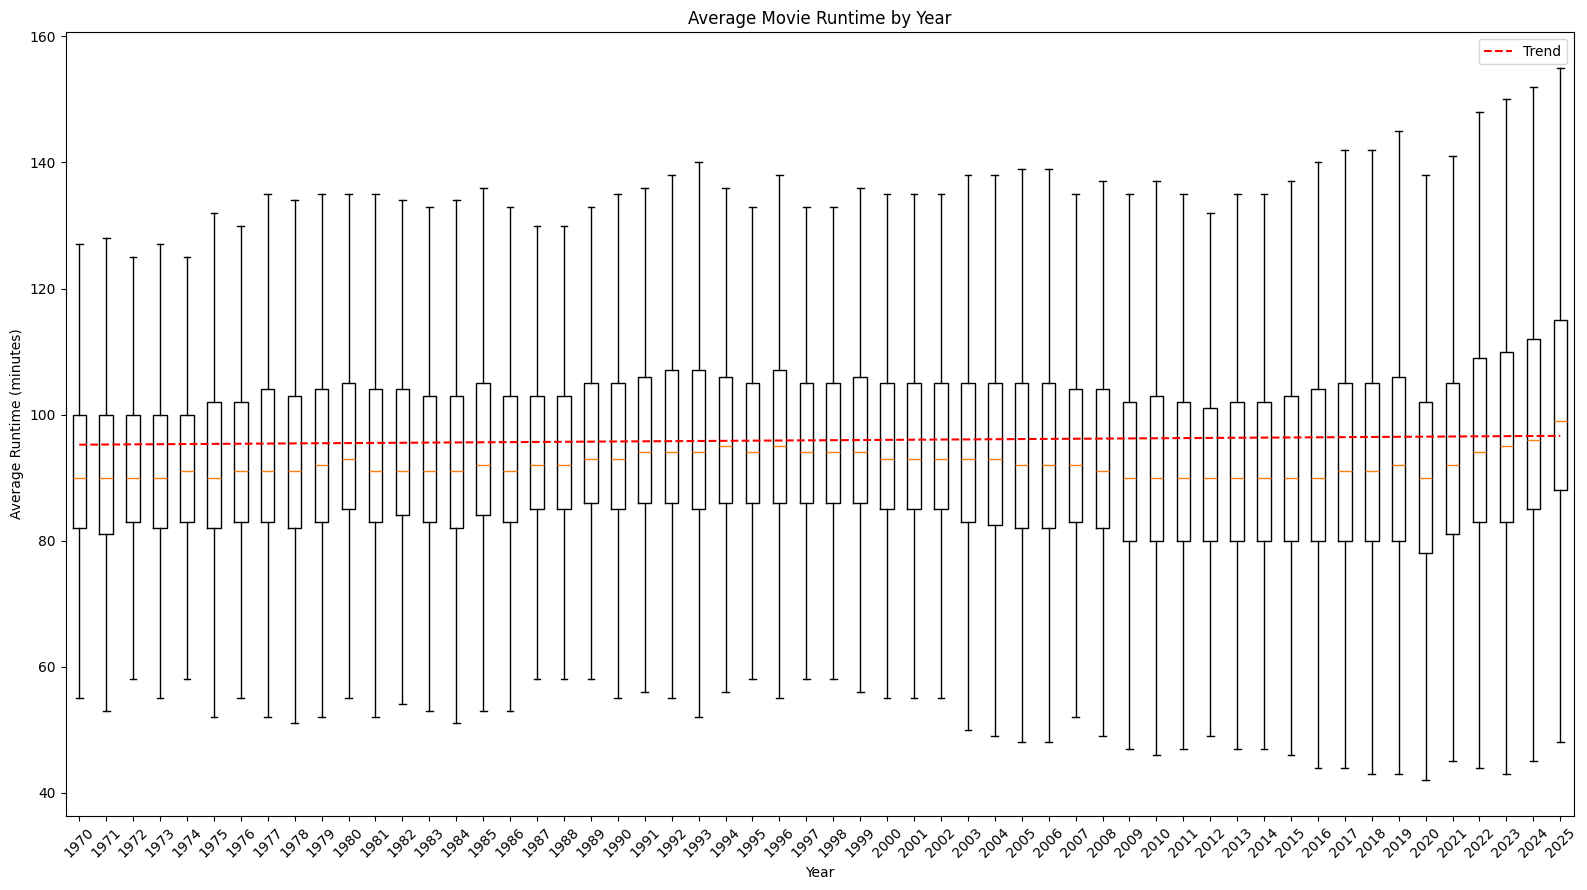

In [14]:
list_of_lists, years, avg_runtimes = mov_period(movies_df, 1970)

fig, ax = plt.subplots(figsize=(16, 9))
ax.boxplot(list_of_lists,
           showfliers=False,
           )


z = np.polyfit(years, avg_runtimes, 1)
p = np.poly1d(z)

#ax.plot(range(1, len(years)+1), avg_runtimes, color='orange', marker='o', label='Average Runtime') #averages line
ax.plot(range(1, len(years)+1), p(years), color='red', linestyle='--', label='Trend') #trendline

ax.set_xlabel('Year')
ax.set_ylabel('Average Runtime (minutes)')
ax.set_title('Average Movie Runtime by Year')

ax.set_xticks(range(1, len(years)+1))
ax.set_xticklabels([str(year) for year in years], rotation=45)
ax.tick_params(axis='x', rotation=(45))

ax.legend()
plt.tight_layout()  # Adjust layout to fit everything

plt.show()

In [ ]:
# Prumerna delka filmu od 70.let
movies_df[movies_df['startYear'] >= 1970]['runtimeMinutes'].mean()

np.float64(95.69449861690235)

In [ ]:
print(mk.original_test(avg_runtimes))

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(10.741463730307363), Tau=np.float64(0.6417322834645669), s=np.float64(5216.0), var_s=235712.0, slope=np.float64(0.23067461409570295), intercept=np.float64(78.78951543231896))


Here’s what each value from the Mann-Kendall test output means:

trend='increasing'
There is an upward trend in your data (average runtimes are increasing over time).

h=np.True_
The test is statistically significant (the trend is real, not random).

p=0.0200...
The p-value (probability the trend is due to chance). Since p < 0.05, the trend is significant.

z=2.33...
The standardized test statistic. Higher absolute values mean a stronger trend.

Tau=0.6
Kendall’s Tau: a measure of correlation (ranges from -1 to 1). 0.6 means a moderate to strong positive association.

s=27.0
The Mann-Kendall S statistic (sum of the signs of all pairwise differences).

var_s=125.0
The variance of S, used to calculate z.

slope=0.698...
The estimated median increase per time unit (here, average runtime increases by about 0.7 minutes per year).

intercept=93.67...
The intercept of the trend line (estimated starting value).

Summary:
There is a statistically significant, moderately strong increasing trend in average movie runtimes since 2016, with runtimes rising by about 0.7 minutes per year.

In [ ]:
#Testování, zda se variance lyší napříč dvěmi obdobími - před a po covidu

list_of_lists, years, avg_runtimes = mov_period(movies_df, 2016)

#mannkendall
print(mk.original_test(avg_runtimes))

### udělej 2015-2019 a 2020-2024

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.020044668622627437), z=np.float64(2.3255106965997814), Tau=np.float64(0.6), s=np.float64(27.0), var_s=125.0, slope=np.float64(0.6977429353858895), intercept=np.float64(93.6657025813529))


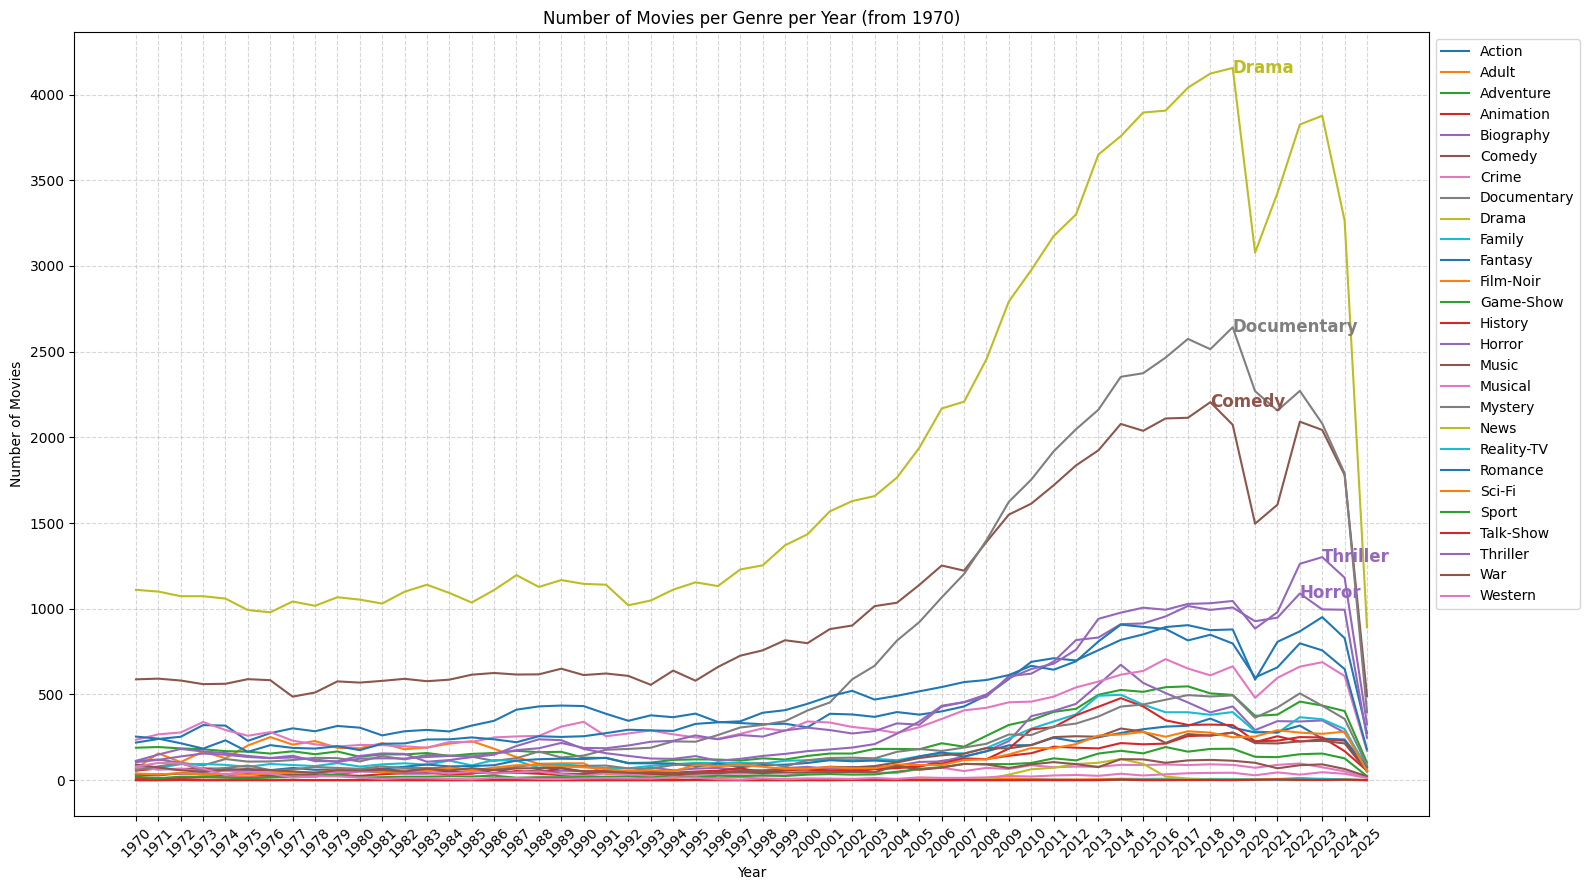

In [6]:
# Set the start year for the plot
start_year = 1970  # Change this to your desired start year

# Split genres into lists
movies_df['genres_split'] = movies_df['genres'].str.split(',')

# Explode so each row is one genre per movie
exploded = movies_df.explode('genres_split')

# Remove missing genres if any
exploded = exploded[exploded['genres_split'] != '\\N']

# Group by year and genre, count movies
genre_counts = exploded.groupby(['startYear', 'genres_split']).size().reset_index(name='count')

# Pivot for plotting
pivot = genre_counts.pivot(index='startYear', columns='genres_split', values='count').fillna(0)

# Filter by start_year
pivot = pivot[pivot.index >= start_year]

fig, ax = plt.subplots(figsize=(16, 9))
lines = {}
for genre in pivot.columns:
    line, = ax.plot(pivot.index, pivot[genre], label=genre)
    lines[genre] = line

# Find the 5 genres with the highest maximum value
top5_genres = pivot.max().sort_values(ascending=False).head(5).index

# Annotate the highest point of each top genre
for genre in top5_genres:
    y_max = pivot[genre].max()
    x_max = pivot.index[pivot[genre].argmax()]
    ax.text(x_max, y_max, genre, fontsize=12, color=lines[genre].get_color(), va='center', ha='left', fontweight='bold',)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Movies')
ax.set_title(f'Number of Movies per Genre per Year (from {start_year})')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_yticks(np.arange(0, pivot.values.max() + 1, 500))
ax.set_xticks(pivot.index)  # Show every year as a tick
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which='both', linestyle='--', alpha=0.5)  # Add grid lines
plt.tight_layout()
plt.show()

In [13]:
# mrkni kolikaprocentni zastoupeni je počet komedie + drama – není to celkové množství filmů?

(len(movies_df[movies_df['genres'].str.contains('Drama', na=False)]) + len(movies_df[movies_df['genres'].str.contains('Comedy', na=False)])) / len(movies_df)

# damn, vypdá to, že 70% filmů má tag, drama, nebo komedie – můžeme to chápat jako nějakou osu vyznění filmu

0.7089800723965415

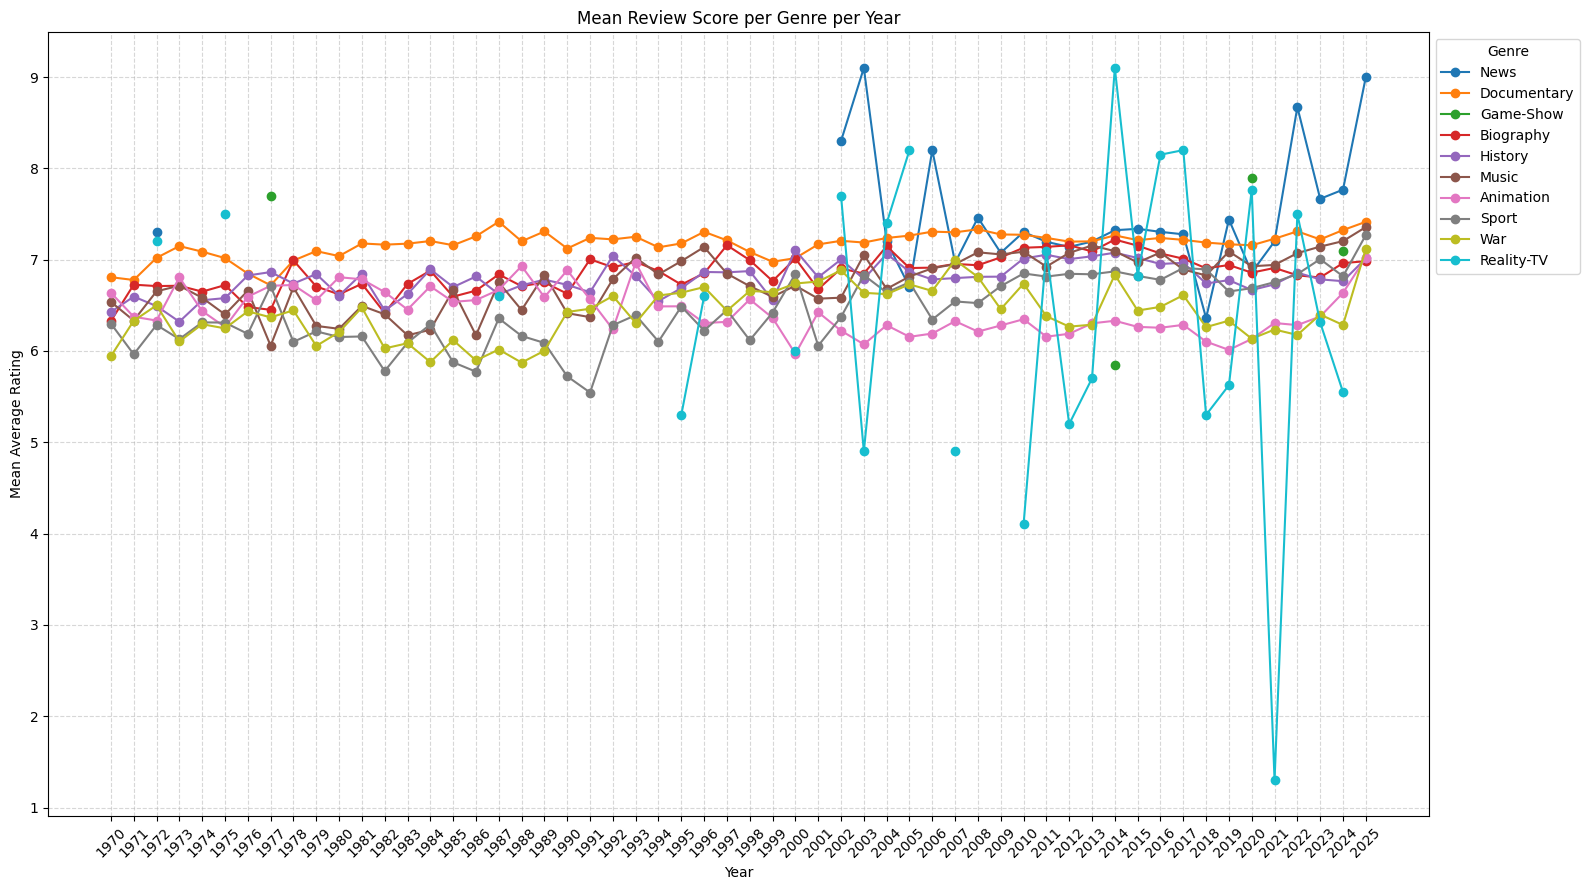

In [15]:
# Group by year and genre, calculate mean rating
genre_ratings = exploded.groupby(['startYear', 'genres_split'])['averageRating'].mean().reset_index()

# Pivot for plotting
pivot_ratings = genre_ratings.pivot(index='startYear', columns='genres_split', values='averageRating')

# Filter by start year if needed (e.g., 1970)
pivot_ratings = pivot_ratings[pivot_ratings.index >= 1970]

# Plot: show only top N genres by overall mean rating (optional)
top_genres = pivot_ratings.mean().sort_values(ascending=False).head(10).index
pivot_ratings[top_genres].plot(figsize=(16, 9), marker='o')

plt.xlabel('Year')
plt.ylabel('Mean Average Rating')
plt.title('Mean Review Score per Genre per Year')
plt.legend(title='Genre', bbox_to_anchor=(1, 1))
plt.xticks(pivot_ratings.index, rotation=45)  # Show every year as a tick
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [46]:
genre_ratings

,startYear,genres_split,averageRating
0,1894,Romance,5.400000
1,1896,Documentary,4.000000
2,1897,Documentary,5.300000
3,1897,News,5.300000
4,1897,Sport,5.300000
...,...,...,...
2533,2025,Sci-Fi,6.177778
2534,2025,Sport,7.269565
2535,2025,Thriller,6.495692
2536,2025,War,7.118182


In [16]:
cutoff_year = 1970  # Set your desired start year

# Filter by cutoff_year
filtered_genre_ratings = genre_ratings[genre_ratings['startYear'] >= cutoff_year]

genres = filtered_genre_ratings['genres_split'].unique()

results = []

for genre in genres:
    genre_data = filtered_genre_ratings[filtered_genre_ratings['genres_split'] == genre].sort_values('startYear')
    x = genre_data['averageRating'].values
    if len(x) > 2:  # Mann-Kendall needs at least 3 points
        test_result = mk.original_test(x)
        results.append({
            'genre': genre,
            'trend': test_result.trend,
            'p': test_result.p,
            'tau': test_result.Tau,
            'slope': test_result.slope,
            'n_years': len(x)
        })

# Convert results to DataFrame for easy viewing
mk_results_df = pd.DataFrame(results)
mk_results_df

,genre,trend,p,tau,slope,n_years
0,Action,no trend,4.245041e-01,-0.074026,-0.001821,56
1,Adult,increasing,3.184900e-05,0.386532,0.025678,55
2,Adventure,increasing,4.934358e-04,0.320779,0.004896,56
3,Animation,decreasing,9.851857e-05,-0.358442,-0.008472,56
4,Biography,increasing,5.418106e-07,0.461039,0.007980,56
5,Comedy,increasing,1.027151e-07,0.489610,0.005836,56
6,Crime,increasing,2.160838e-05,0.390909,0.004394,56
7,Documentary,increasing,5.890281e-06,0.416883,0.004158,56
8,Drama,increasing,6.006336e-09,0.535065,0.004398,56
9,Family,decreasing,6.508458e-03,-0.250649,-0.005338,56


ukazuje to, že „mrtvý žánry“ mají sestupnou tendenci na hodnoceních uživatelů